<a href="https://colab.research.google.com/github/brunosolimoes/RL_CartPole_Qlearning/blob/main/RL_CartPole_Qlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium
!pip install matplotlib
!pip install numpy

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

print("Espaço de ações:", env.action_space)
print("Espaço de observações:", env.observation_space)

Espaço de ações: Discrete(2)
Espaço de observações: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [4]:
rewards = []

for episode in range(10):

    obs, info = env.reset()

    total_reward = 0

    done = False

    while not done:

        action = env.action_space.sample()

        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        done = terminated or truncated

    rewards.append(total_reward)

    print(
        f"Episódio {episode+1}:",
        total_reward
    )

Episódio 1: 21.0
Episódio 2: 31.0
Episódio 3: 40.0
Episódio 4: 24.0
Episódio 5: 31.0
Episódio 6: 13.0
Episódio 7: 22.0
Episódio 8: 23.0
Episódio 9: 41.0
Episódio 10: 19.0


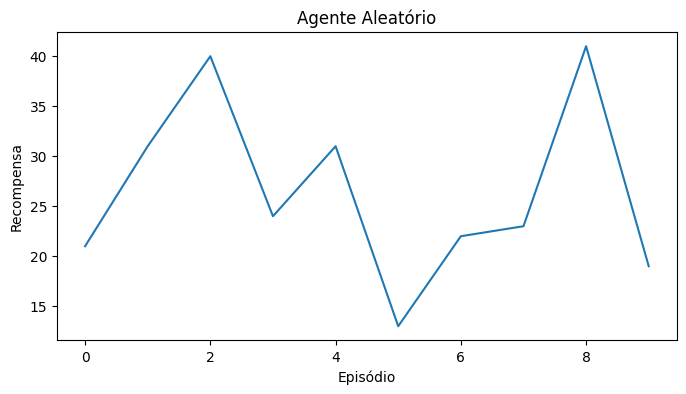

In [5]:
plt.figure(figsize=(8,4))

plt.plot(rewards)

plt.xlabel("Episódio")

plt.ylabel("Recompensa")

plt.title("Agente Aleatório")

plt.show()

# Teste inicial

Foi criado um agente aleatório para validar o ambiente.

Como o agente escolhe ações sem aprendizado,
as recompensas permanecem baixas.

In [8]:
import numpy as np

NUM_BINS = 20

bins = [
    np.linspace(-4.8,4.8,NUM_BINS),
    np.linspace(-4,4,NUM_BINS),
    np.linspace(-0.418,0.418,NUM_BINS),
    np.linspace(-4,4,NUM_BINS)
]

In [9]:
def discretize(state):

    state_adj=[]

    for i in range(len(state)):

        idx=np.digitize(state[i],bins[i])

        state_adj.append(idx)

    return tuple(state_adj)

In [10]:
obs,info = env.reset()

print(obs)

print(discretize(obs))

[-0.01531665  0.03092031 -0.02824784  0.03507191]
(np.int64(10), np.int64(10), np.int64(9), np.int64(10))


In [11]:
q_table = np.zeros(
    (
        NUM_BINS+1,
        NUM_BINS+1,
        NUM_BINS+1,
        NUM_BINS+1,
        env.action_space.n
    )
)

print(q_table.shape)

(21, 21, 21, 21, 2)


In [12]:
learning_rate = 0.1

discount = 0.99

epsilon = 1.0

epsilon_decay = 0.995

min_epsilon = 0.01

episodes = 2000

In [13]:
rewards_per_episode=[]

for episode in range(episodes):

    obs,info=env.reset()

    state=discretize(obs)

    done=False

    total_reward=0

    while not done:

        if np.random.random()<epsilon:

            action=env.action_space.sample()

        else:

            action=np.argmax(
                q_table[state]
            )

        new_obs,reward,terminated,truncated,info=env.step(action)

        done=terminated or truncated

        new_state=discretize(new_obs)

        old_value=q_table[state+(action,)]

        next_max=np.max(
            q_table[new_state]
        )

        new_value=(1-learning_rate)*old_value + \
                  learning_rate*(
                      reward+
                      discount*
                      next_max
                  )

        q_table[state+(action,)]=new_value

        state=new_state

        total_reward+=reward

    epsilon=max(
        min_epsilon,
        epsilon*epsilon_decay
    )

    rewards_per_episode.append(
        total_reward
    )

    if episode%100==0:

        print(
            "Episode:",
            episode,
            "Reward:",
            total_reward
        )

Episode: 0 Reward: 46.0
Episode: 100 Reward: 18.0
Episode: 200 Reward: 72.0
Episode: 300 Reward: 72.0
Episode: 400 Reward: 81.0
Episode: 500 Reward: 19.0
Episode: 600 Reward: 22.0
Episode: 700 Reward: 20.0
Episode: 800 Reward: 67.0
Episode: 900 Reward: 59.0
Episode: 1000 Reward: 69.0
Episode: 1100 Reward: 72.0
Episode: 1200 Reward: 69.0
Episode: 1300 Reward: 89.0
Episode: 1400 Reward: 76.0
Episode: 1500 Reward: 77.0
Episode: 1600 Reward: 29.0
Episode: 1700 Reward: 32.0
Episode: 1800 Reward: 30.0
Episode: 1900 Reward: 82.0


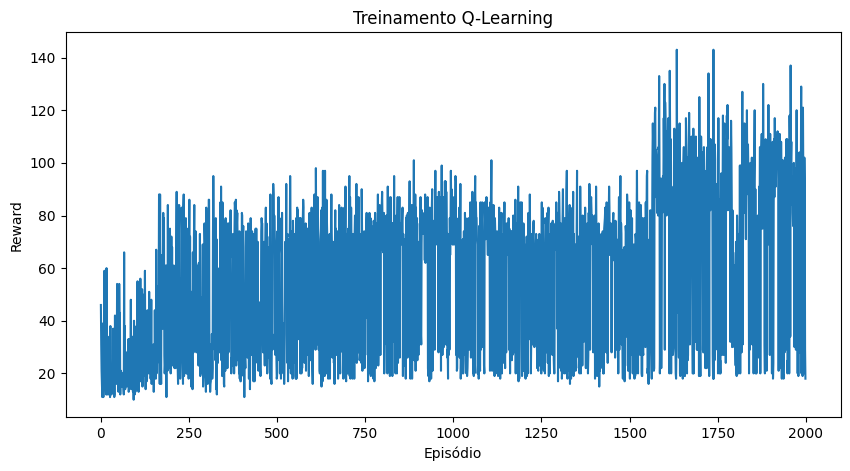

In [14]:
plt.figure(figsize=(10,5))

plt.plot(rewards_per_episode)

plt.xlabel("Episódio")

plt.ylabel("Reward")

plt.title(
    "Treinamento Q-Learning"
)

plt.show()

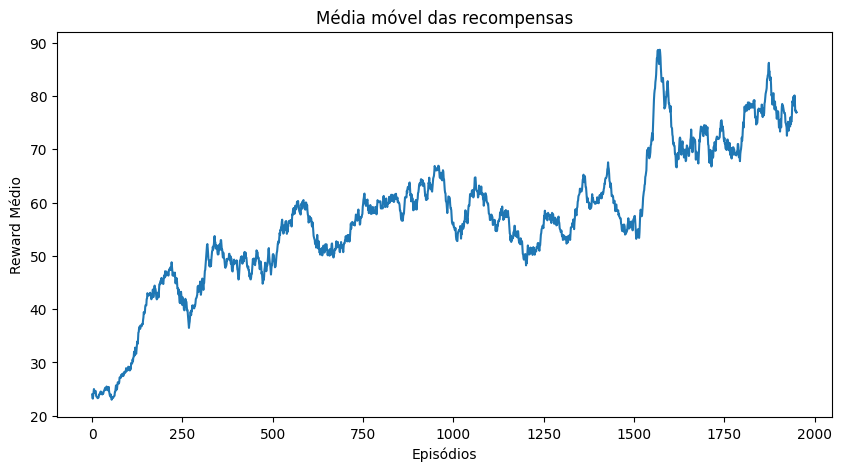

In [15]:
window=50

moving_avg=np.convolve(
    rewards_per_episode,
    np.ones(window)/window,
    mode='valid'
)

plt.figure(figsize=(10,5))

plt.plot(moving_avg)

plt.title(
    "Média móvel das recompensas"
)

plt.xlabel("Episódios")

plt.ylabel("Reward Médio")

plt.show()
